In [1]:
import copy
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

from src.evaluation import inference
from src.data.read_write import n_events_in_part


In [2]:
model_path = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_05__19_20_26/checkpoints/2026-08-06_11-20-44_model.pt"
model_name = os.path.basename(model_path)
model_dir = os.path.dirname(model_path)
output_path = os.path.join(model_dir, model_name.split(".")[0] + "_testset.npy")
physical_output = output_path.replace(".npy", "_physical.npy")
cells_output = output_path.replace(".npy", "_cells.npy")

sampler = inference.Sampler.from_model_path(model_path)
total_test_size = n_events_in_part(sampler.config, "test")
config = sampler.config

In [3]:
sample = np.load(output_path)
cond, points, target = sampler.get_cond("test", total_size=len(sample), return_target=True)

Selecting evenly spaced events


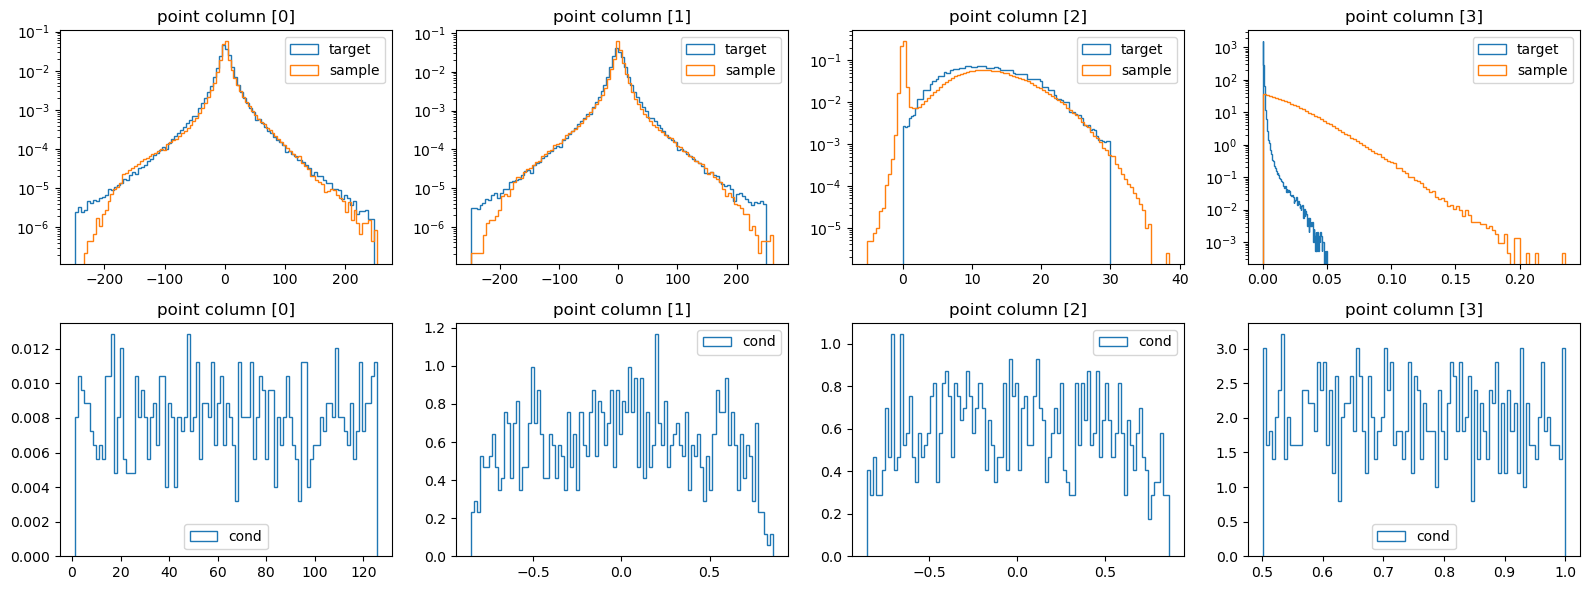

In [4]:
def real_points(points):
    flat = points.reshape(-1, points.shape[-1])
    return flat[flat[:, 3] > 0]


t_real = real_points(target)
s_real = real_points(sample)

n_cols = t_real.shape[-1]
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 6))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes[0]):
    ax.hist(
        t_real[:, i],
        bins=100,
        histtype="step",
        density=True,
        label="target",
    )
    ax.hist(
        s_real[:, i],
        bins=100,
        histtype="step",
        density=True,
        label="sample",
    )
    ax.set_title(f"point column [{i}]")
    ax.legend()
    ax.semilogy()
    
for i, ax in enumerate(axes[1]):
    ax.hist(
        cond[:, i],
        bins=100,
        histtype="step",
        density=True,
        label="cond",
    )

    ax.set_title(f"point column [{i}]")
    ax.legend()
fig.tight_layout()
plt.show()

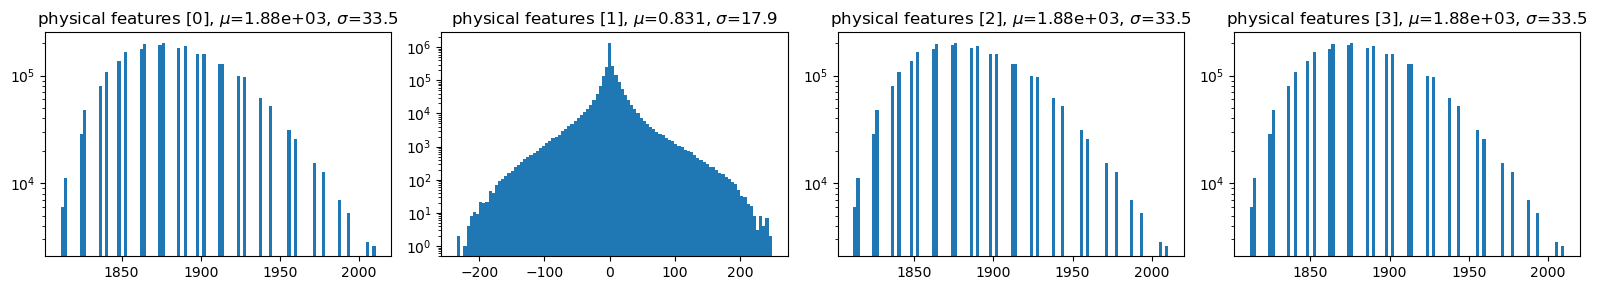

In [5]:
def plot_columns(data, title):
    data = data.reshape(-1, data.shape[-1])
    n_cols = data.shape[-1]
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 3))
    axes = np.atleast_1d(axes)
    for i, ax in enumerate(axes):
        vals = data[:, i]
        ax.hist(vals, bins=100)
        mean = np.mean(vals)
        std = np.std(vals)
        ax.set_title(f"{title} [{i}], $\\mu$={mean:.3}, $\\sigma$={std:.3}")
        ax.semilogy()
    fig.tight_layout()
    return fig

physical = np.load(physical_output)

real_features = physical[physical[..., 3]>0]
plot_columns(real_features, "physical features")
plt.show()

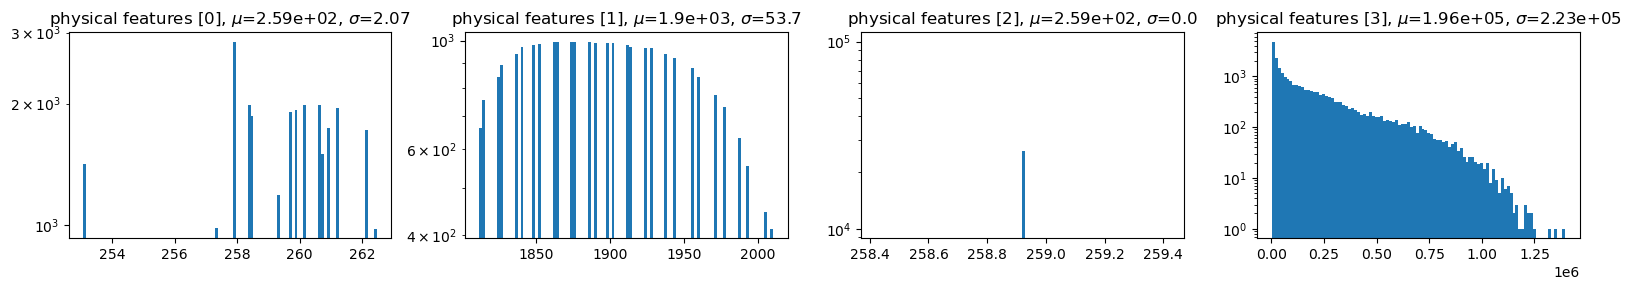

In [6]:

cells = np.load(cells_output)

real_features = cells[cells[..., 3]>0]
plot_columns(real_features, "physical features")
plt.show()